# DEA Notebook 
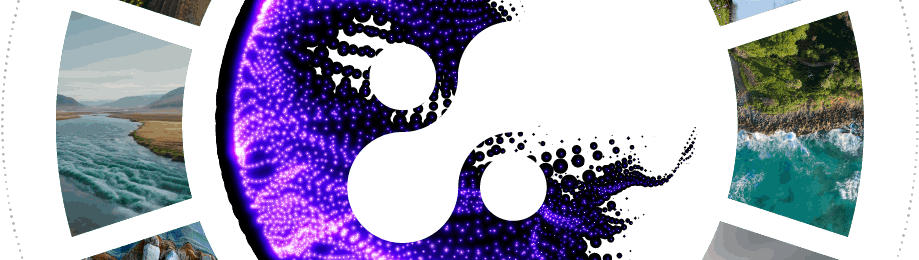



### [DEA](https://dea.destine.eu/web) is a Content creation service and no-code platform for DestinE storytelling and data visualisation

# INFOMAR Bathymetry GeoTIFF → KMZ for DEA

## Introduction

**INFOMAR** (Integrated Mapping for the Sustainable Development of Ireland's Marine Resource) is a joint programme between the Geological Survey Ireland and the Marine Institute. It provides high-resolution bathymetric surveys of Irish coastal and offshore waters.

This notebook converts a single-band float32 bathymetry GeoTIFF from SURVEY into a **KMZ GroundOverlay** suitable for use as a DEA asset.

Data downloaded from the [INFOMAR Data Download Portal](https://experience.arcgis.com/experience/3f2815ec89e745d2b65630429d06385c/page/Page-1?views=Download-Survey-Leg-Data).
```
https://gsi.geodata.gov.ie/downloads/Marine/Data/Downloads/2003/CV03_01/BY_CV03_01_Dublin_5m_U29N_LAT_TIFF_Inshore_Ireland.zip
```

### What we produce
| File | Content |
|---|---|
| `BY_CV03_01_Dublin_bathy_full.kmz` | Coloured bathymetry raster as a KMZ GroundOverlay |

## 0. Download data

In [ ]:
import urllib.request
import zipfile
from pathlib import Path

INPUTS_DIR = Path("inputs")
INPUTS_DIR.mkdir(exist_ok=True)

downloads = {
    "BY_CV03_01_Dublin_5m_U29N_LAT_TIFF_Inshore_Ireland.zip": (
        "https://gsi.geodata.gov.ie/downloads/Marine/Data/Downloads/"
        "2003/CV03_01/BY_CV03_01_Dublin_5m_U29N_LAT_TIFF_Inshore_Ireland.zip"
    ),
}

for filename, url in downloads.items():
    dest        = INPUTS_DIR / filename
    extract_dir = INPUTS_DIR / filename.replace(".zip", "")

    if extract_dir.exists():
        print(f"Already extracted, skipping: {filename}")
        continue

    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, dest)
    print(f"Saved: {dest.name}  ({dest.stat().st_size/1024:.0f} KB)")

    print(f"Extracting to {extract_dir}...")
    with zipfile.ZipFile(dest, 'r') as z:
        z.extractall(extract_dir)
    dest.unlink()
    print(f"Done.")

## 1. Setup

This notebook requires the following libraries, all available in the `dublin_bay` conda environment:

In [ ]:
import io
import zipfile
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from PIL import Image

## 2. Configuration [EDIT HERE YOUR SETTINGS]

All parameters that may need to be changed are defined here: file paths, resolution, transparency, and colormap control points.

In [ ]:
INPUT_TIF  = Path("inputs/BY_CV03_01_Dublin_5m_U29N_LAT_TIFF_Inshore_Ireland/BY_CV03_01_Dublin_5m_U29N.tif")
OUTPUT_KMZ = Path("outputs/BY_CV03_01_Dublin_bathy_full.kmz")

# Downsample factor — higher = smaller file, lower resolution
# 1 = full resolution (5m), 10 = ~50m resolution (good for web overview)
SCALE_FACTOR = 1

# Transparency of the overlay (0 = fully transparent, 255 = fully opaque)
ALPHA = 210

# Color range clipping — percentiles to avoid outlier stretching
VMIN_PERCENTILE = 2
VMAX_PERCENTILE = 98

# Colormap control points — depth values mapped to RGB
# Format: (t, r, g, b) where t is normalised depth (0 = deep, 1 = shallow)
COLORMAP_POINTS = [
    (0.0,   8,  24,  80),   # deep — dark blue
    (0.4,  20,  80, 140),
    (0.7,  40, 140, 190),
    (1.0, 100, 200, 230),   # shallow — cyan
]

DST_CRS = "EPSG:4326"

## 3. Load and Inspect the GeoTIFF [OPTIONAL]

In [ ]:
with rasterio.open(INPUT_TIF) as src:
    print(f"File       : {INPUT_TIF.name}")
    print(f"CRS        : {src.crs}")
    print(f"Size       : {src.width} x {src.height} px")
    print(f"Resolution : {src.res[0]:.1f}m")
    print(f"NoData     : {src.nodata}")
    print(f"Bounds     : {src.bounds}")

## 4. Coordinate Reference System

The INFOMAR GeoTIFF is projected in **UTM** (Universal Transverse Mercator), a metric CRS that expresses positions as eastings and northings in metres. This is well suited for spatial analysis but cannot be used directly by DEA.

**DEA (CesiumJS) requires all raster overlays to be in EPSG:4326 (WGS84)** — the geographic coordinate system that uses longitude and latitude in decimal degrees. This is the standard for web mapping and the only CRS Cesium accepts for `GroundOverlay` positioning.

The reprojection is performed with `rasterio.warp.reproject`, which resamples the pixel grid from the UTM projection to the WGS84 geographic grid.

In [ ]:
with rasterio.open(INPUT_TIF) as src:
    out_w = src.width  // SCALE_FACTOR
    out_h = src.height // SCALE_FACTOR

    transform, width, height = calculate_default_transform(
        src.crs, DST_CRS, out_w, out_h, *src.bounds
    )

    data = np.zeros((height, width), dtype=np.float32)
    reproject(
        source=rasterio.band(src, 1),
        destination=data,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=DST_CRS,
        resampling=Resampling.average,
        src_nodata=src.nodata,
        dst_nodata=np.nan
    )

    bounds_wgs84 = transform_bounds(src.crs, DST_CRS, *src.bounds)

west, south, east, north = bounds_wgs84
print(f"Reprojected : {width} x {height} px  ({DST_CRS})")
print(f"Bounds      : W={west:.4f}  S={south:.4f}  E={east:.4f}  N={north:.4f}")

## 5. Colormap

Bathymetry data is a continuous field of depth values. To visualise it as an image, each depth value is mapped to a colour using a **colormap**.

The colormap is defined as a set of control points in the `COLORMAP_POINTS` configuration variable. Each point maps a normalised depth value (`0` = deepest, `1` = shallowest) to an RGB colour. Values between control points are linearly interpolated.

The depth range used for normalisation is clipped to the `VMIN_PERCENTILE`–`VMAX_PERCENTILE` range to avoid outlier pixels dominating the colour scale.

In [ ]:
def bathy_colormap(t: np.ndarray) -> tuple:
    """Map normalised depth values (0=deep, 1=shallow) to RGB uint8 arrays."""
    ts = [p[0] for p in COLORMAP_POINTS]
    r  = np.interp(t, ts, [p[1] for p in COLORMAP_POINTS]).astype(np.uint8)
    g  = np.interp(t, ts, [p[2] for p in COLORMAP_POINTS]).astype(np.uint8)
    b  = np.interp(t, ts, [p[3] for p in COLORMAP_POINTS]).astype(np.uint8)
    return r, g, b


valid = data[~np.isnan(data)]
vmin  = np.percentile(valid, VMIN_PERCENTILE)
vmax  = np.percentile(valid, VMAX_PERCENTILE)

print(f"Depth range (full)    : {valid.min():.1f}m to {valid.max():.1f}m")
print(f"Depth range (colormap): {vmin:.1f}m to {vmax:.1f}m  (p{VMIN_PERCENTILE}-p{VMAX_PERCENTILE})")

## 6. Generate KMZ

A **KMZ** is a zipped KML file. For raster overlays, it packages two files:
- `doc.kml` — a `<GroundOverlay>` that positions the image on the globe using `<LatLonBox>`
- `bathy.png` — the colourised raster image (RGBA, with nodata pixels set to fully transparent)

In [ ]:
norm = np.clip((data - vmin) / (vmax - vmin), 0, 1)
norm = np.where(np.isnan(norm), 0, norm)   # <-- aggiungere questa riga
mask = ~np.isnan(data)

rgba    = np.zeros((height, width, 4), dtype=np.uint8)
r, g, b = bathy_colormap(norm)
rgba[mask, 0] = r[mask]
rgba[mask, 1] = g[mask]
rgba[mask, 2] = b[mask]
rgba[mask, 3] = ALPHA
rgba[~mask, 3] = 0      # nodata = fully transparent

img = Image.fromarray(rgba, "RGBA")

kml = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <GroundOverlay>
    <name>Dublin Bay — INFOMAR Bathymetry 5m</name>
    <description>INFOMAR survey {INPUT_TIF.stem}. Depth range: {valid.min():.1f}m to {valid.max():.1f}m (LAT).</description>
    <Icon>
      <href>bathy.png</href>
      <viewBoundScale>1.0</viewBoundScale>
    </Icon>
    <LatLonBox>
      <north>{north}</north>
      <south>{south}</south>
      <east>{east}</east>
      <west>{west}</west>
    </LatLonBox>
  </GroundOverlay>
</kml>"""

buf_png = io.BytesIO()
img.save(buf_png, format="PNG", optimize=True)
buf_png.seek(0)

OUTPUT_KMZ.parent.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(OUTPUT_KMZ, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("doc.kml", kml)
    zf.writestr("bathy.png", buf_png.read())

size_mb = OUTPUT_KMZ.stat().st_size / 1024 / 1024
print(f"Saved : {OUTPUT_KMZ.name}")
print(f"Size  : {size_mb:.2f} MB")

## 7. Upload the KML file to DEA and use it in a story

### You can now upload the generated KML file to the [DEA Story Editor](https://dea.destine.eu/stories/editor).

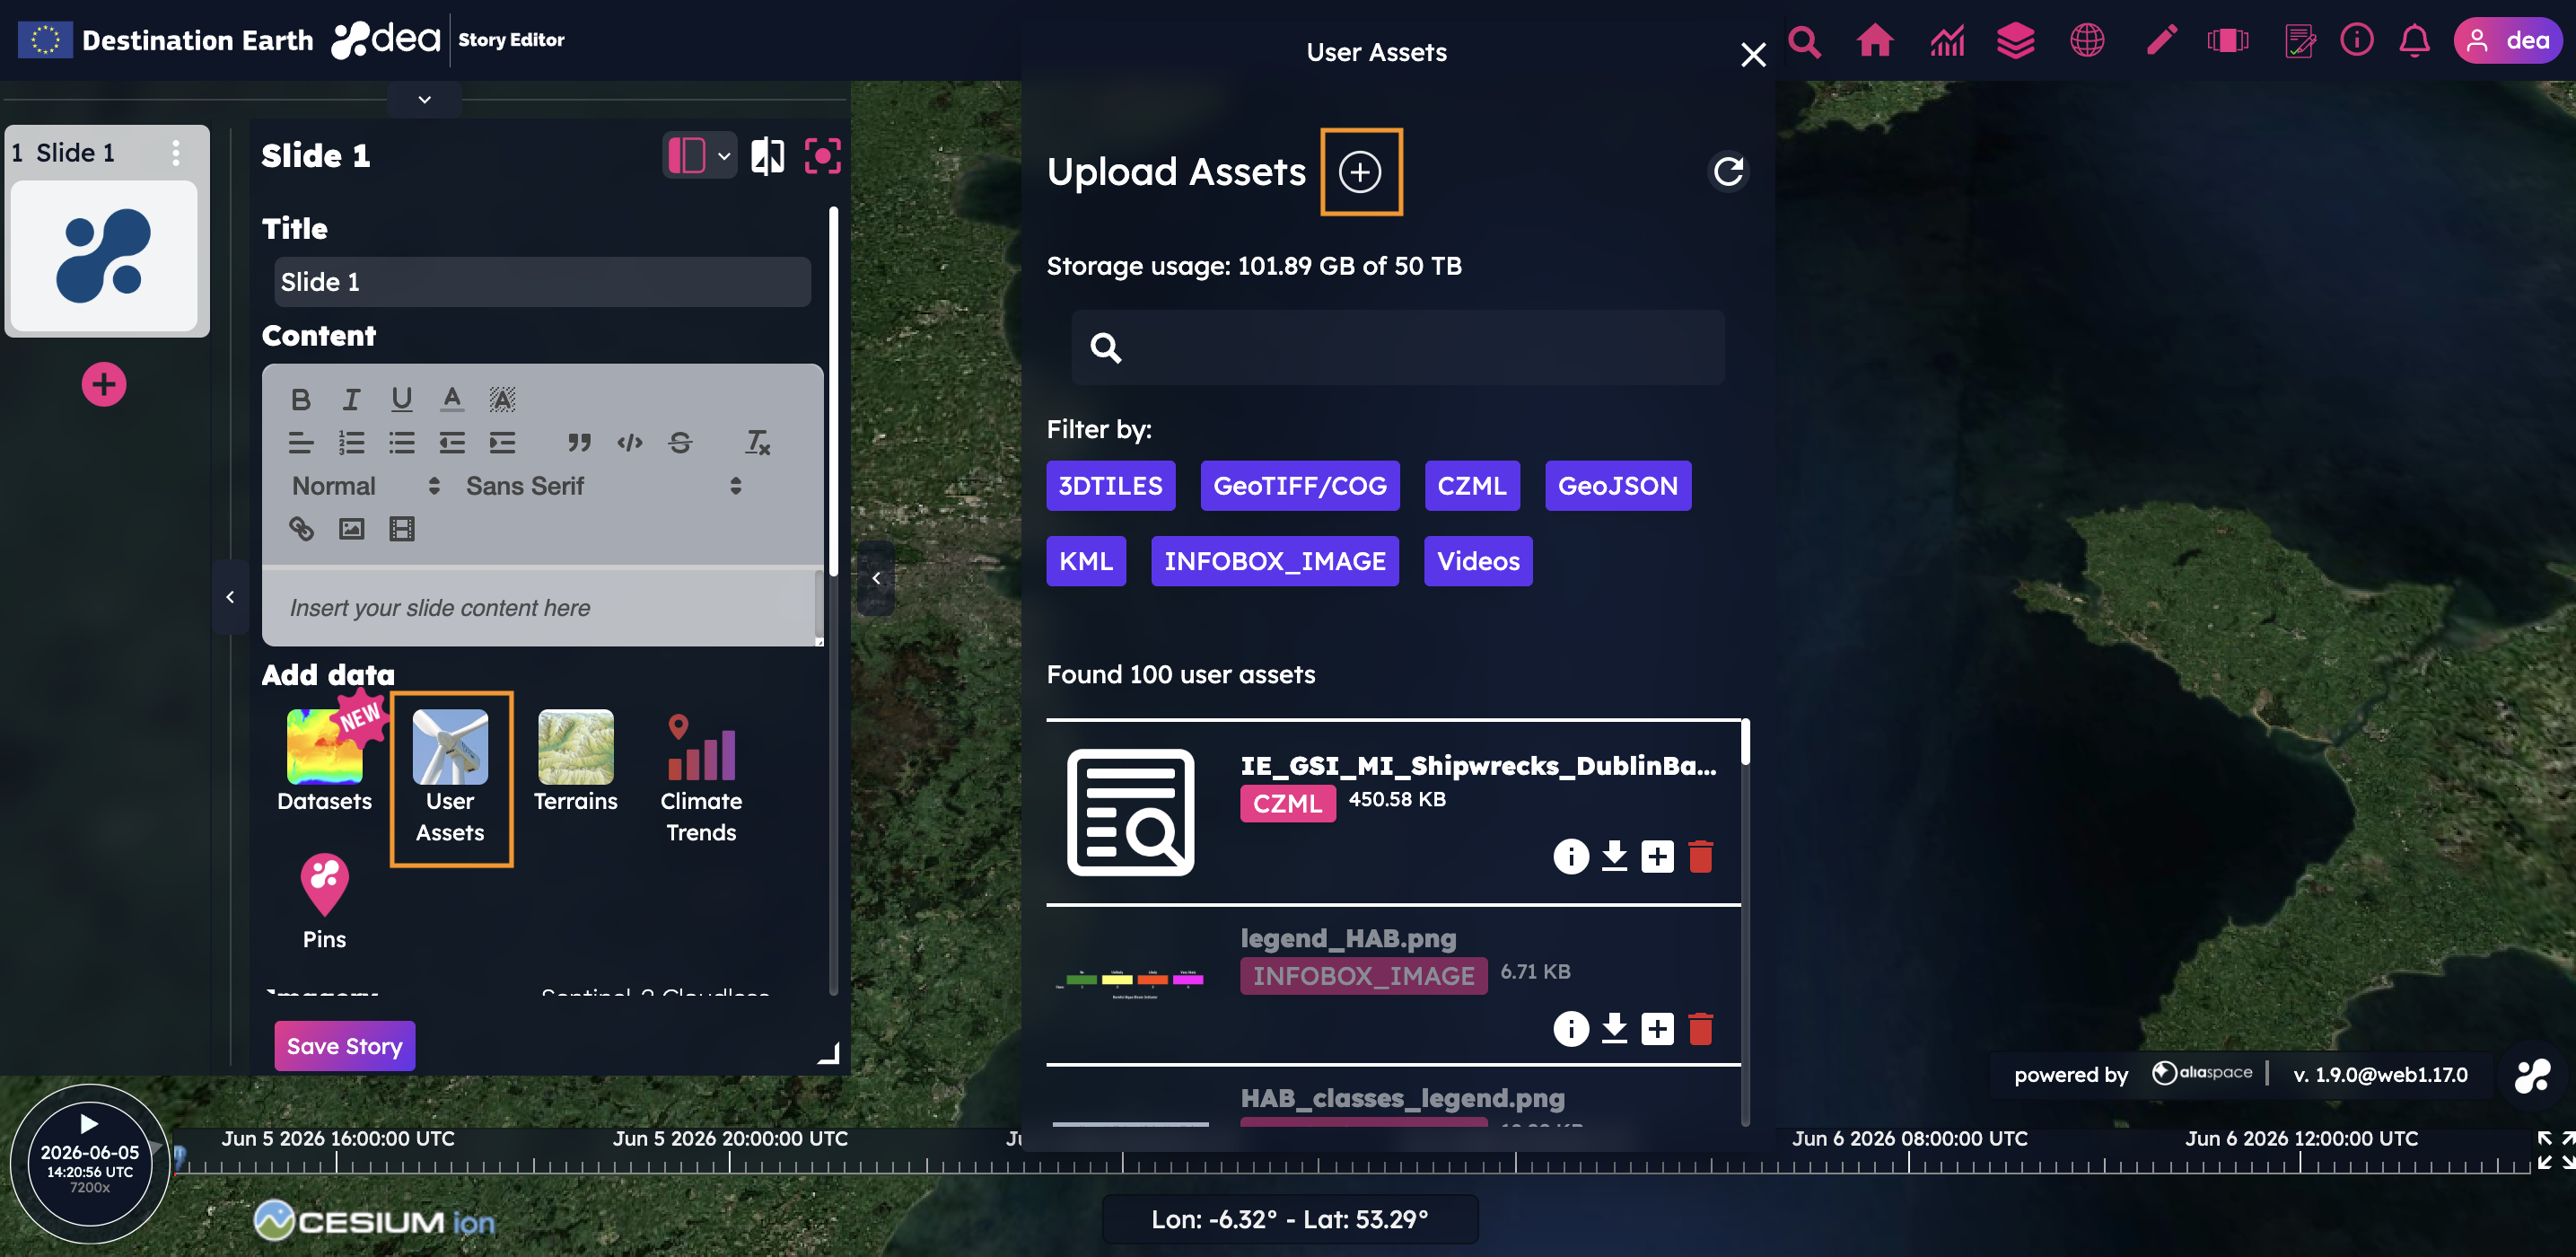

### The asset can be included in your stories.

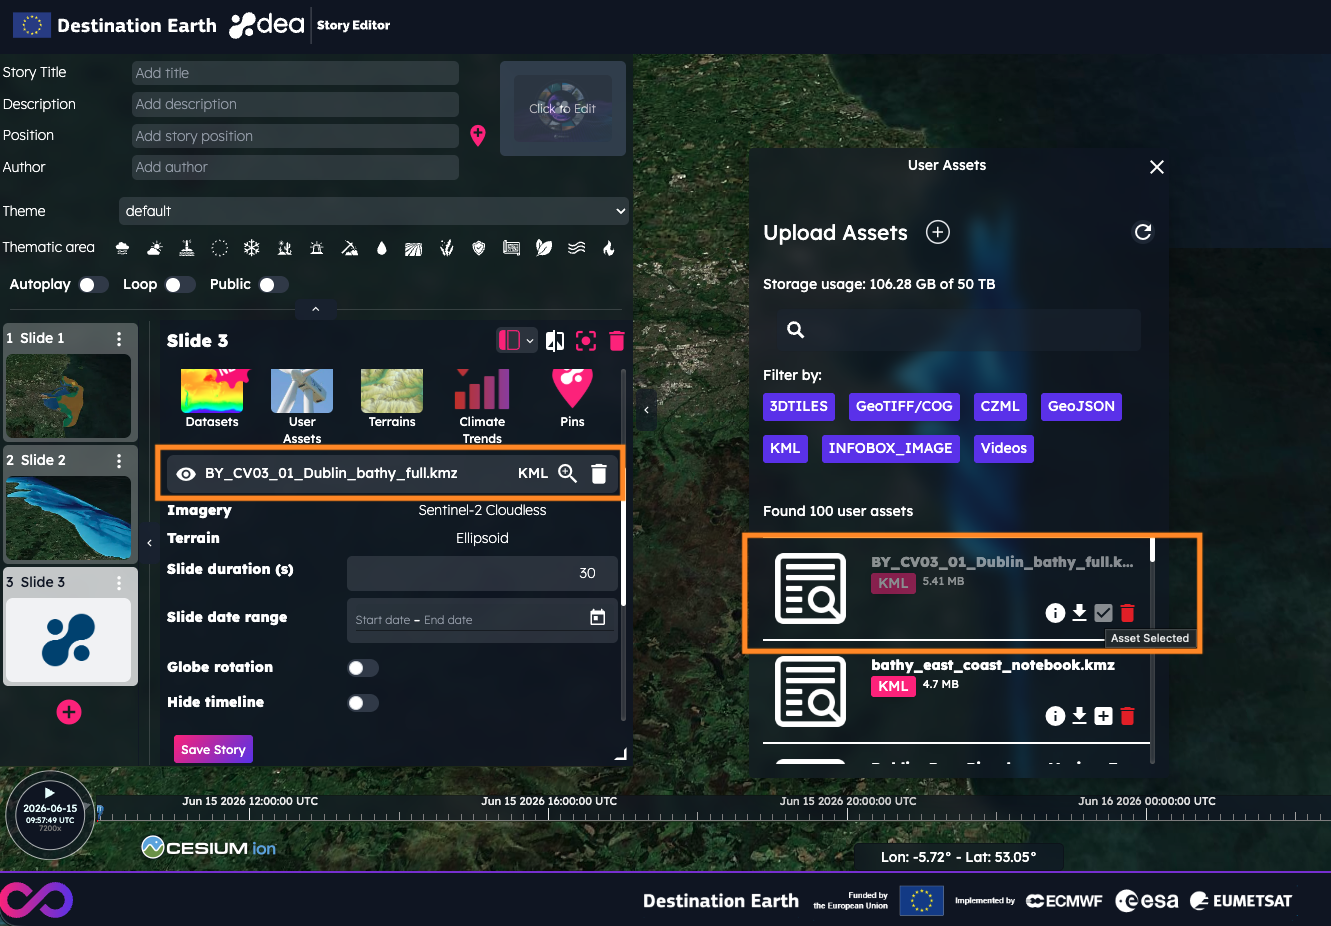

### Timeline settings

As the layer is static, simply hide the timeline.


<center style="font-size: 40pt;"><b>Hope you love it!</b></center>

<div>
    <center>
        <img src="../figures/result_bathy_survey.png" width="800"/>
    </center>
</div>

<center style="font-size: 30pt;">
    <a href="mailto:dea-support@alia-space.com">dea-support@alia-space.com</a>
</center>
<br>